# **Kaggle – DataTops®**
Tu TA ha decidido cambiar de aires y, por eso, ha comprado una tienda de portátiles. Sin embargo, su única especialidad es Data Science, por lo que ha decidido crear un modelo de ML para establecer los mejores precios.

¿Podrías ayudar a tu profe a mejorar ese modelo?

## Aspectos importantes
- Última submission:
    - Mañana: 17 de febrero a las 5pm
    - Tarde: 19 de febrero a las 5pm
- **Enlace de la competición**: https://www.kaggle.com/t/c5cc87b50c4b4770bdc8f5acbe15577d
- **Requisito**: Estar registrado en [Kaggle](https://www.kaggle.com/)

## Métrica:
El error cuadrático medio (RMSE, por sus siglas en inglés) es una medida de la desviación estándar de los residuos (errores de predicción). Los residuos representan la diferencia entre los valores observados y los valores predichos por el modelo. El RMSE indica qué tan dispersos están estos errores: cuanto menor es el RMSE, más cercanas están las predicciones a los valores reales. En otras palabras, el RMSE mide qué tan bien se ajusta la línea de regresión a los datos.


$$ RMSE = \sqrt{\frac{1}{n}\Sigma_{i=1}^{n}{\Big(\frac{d_i -f_i}{\sigma_i}\Big)^2}}$$


## 1. Librerías

In [179]:
import numpy as np
import pandas as pd
from PIL import Image
from sklearn.model_selection import train_test_split,  cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import root_mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
import urllib.request
import seaborn as sns
import matplotlib.pyplot as plt
import toolbox_ML_v2 as tl
import re
import bootcampviztools as bt

from transformer import (
    transformer_screenresolution,
    transformer_cpu,
    transformer_memory,
    transformer_gpu,
    transformer_weight,
    transformer_ram,)

## 2. Datos

In [198]:
# Para que funcione necesitas bajarte los archivos de datos de Kaggle
df = pd.read_csv("./data/train.csv", index_col = 'laptop_ID')
df.head()

,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_in_euros
laptop_ID,,,,,,,,,,,,
755,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i3 6006U 2GHz,8GB,256GB SSD,Intel HD Graphics 520,Windows 10,1.86kg,539.00
618,Dell,Inspiron 7559,Gaming,15.6,Full HD 1920x1080,Intel Core i7 6700HQ 2.6GHz,16GB,1TB HDD,Nvidia GeForce GTX 960<U+039C>,Windows 10,2.59kg,879.01
909,HP,ProBook 450,Notebook,15.6,Full HD 1920x1080,Intel Core i7 7500U 2.7GHz,8GB,1TB HDD,Nvidia GeForce 930MX,Windows 10,2.04kg,900.00
2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,898.94
286,Dell,Inspiron 3567,Notebook,15.6,Full HD 1920x1080,Intel Core i3 6006U 2.0GHz,4GB,1TB HDD,AMD Radeon R5 M430,Linux,2.25kg,428.00


### 2.1 Exploración de los datos

In [199]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 912 entries, 755 to 229
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Company           912 non-null    object 
 1   Product           912 non-null    object 
 2   TypeName          912 non-null    object 
 3   Inches            912 non-null    float64
 4   ScreenResolution  912 non-null    object 
 5   Cpu               912 non-null    object 
 6   Ram               912 non-null    object 
 7   Memory            912 non-null    object 
 8   Gpu               912 non-null    object 
 9   OpSys             912 non-null    object 
 10  Weight            912 non-null    object 
 11  Price_in_euros    912 non-null    float64
dtypes: float64(2), object(10)
memory usage: 92.6+ KB


In [200]:
# df.head()

In [201]:
# df.tail()

In [202]:
# df.describe()

| Columna          | Qué significa                                                                |
| ---------------- | ---------------------------------------------------------------------------- |
| Company          | Marca (Dell, HP, Apple, Lenovo, etc.)                                        |
| Product          | Nombre/modelo comercial (ej. “XPS 13”, “MacBook Pro”)                        |
| TypeName         | Tipo/form factor (Ultrabook, Gaming, Notebook, Workstation, 2-in-1)          |
| Inches           | Tamaño de pantalla en pulgadas                                               |
| ScreenResolution | Resolución y tipo de panel (ej. “1920x1080”, “IPS”, “Touchscreen”, “4K”)     |
| Cpu              | Procesador (marca + línea + modelo + frecuencia; ej. “Intel Core i7 2.7GHz”) |
| Ram              | Memoria RAM (ej. “8GB”)                                                      |
| Memory           | Almacenamiento (ej. “256GB SSD”, “1TB HDD”, “128GB SSD + 1TB HDD”)           |
| Gpu              | Placa gráfica (ej. “Nvidia GeForce GTX 1050”, “Intel HD Graphics”)           |
| OpSys            | Sistema operativo (Windows, macOS, Linux, No OS)                             |
| Weight           | Peso (ej. “1.37kg”)                                                          |


### 2.3 Definir X e y

In [203]:
X = df.drop(['Price_in_euros'], axis=1)
y = df['Price_in_euros'].copy()

### 2.4 Dividir X_train, X_test, y_train, y_test

In [204]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state = 42)

In [205]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)

(729, 11)
(183, 11)
(729,)


## 3. Procesado de datos

Nuestro target es la columna `Price_in_euros`

In [206]:
target = 'Price_in_euros'

In [207]:
# X_train.tail()

In [208]:
for col in X_train.columns:
    print(f'{col}: {X_train[col].nunique()}=')
    print(X_train[col].value_counts())
    print('\n')

Company: 17=
Company
Lenovo       162
Dell         158
HP           155
Asus         101
Acer          55
Toshiba       31
MSI           30
Apple         13
Mediacom       4
Razer          4
Xiaomi         3
Samsung        3
Microsoft      3
Google         2
Fujitsu        2
Vero           2
Chuwi          1
Name: count, dtype: int64


Product: 408=
Product
XPS 13                                     20
Inspiron 3567                              17
250 G6                                     12
ProBook 450                                12
EliteBook 840                              11
                                           ..
V330-15IKB (i5-8250U/4GB/256GB/FHD/W10)     1
Thinkpad T460s                              1
ThinkPad T460                               1
17-BS092ND (i3-6006U/8GB/256GB/W10)         1
SP315-51 (i7-7500U/12GB/1TB/FHD/W10)        1
Name: count, Length: 408, dtype: int64


TypeName: 6=
TypeName
Notebook              412
Gaming                113
Ultrabook          

#### Columna Product

Esta columna tiene muchísimos valores distintos (cardinalidad muy alta), lo que haría que un one-hot genere demasiadas columnas y ruido. Además, suele funcionar más como un identificador/etiqueta específica que como una señal general. Por eso la eliminamos del dataset antes de entrenar.

#### Tratamiento de columnas Company, TypeName y OpSys (One-Hot Encoding)

A Company, TypeName y OpSys les hago One-Hot Encoding porque son datos tipo “etiqueta” (marca, tipo de laptop y sistema operativo). No tienen un orden numérico real. Con one-hot, cada opción se transforma en una columna 0/1 y el modelo puede aprender su efecto sin confundirse. 

In [194]:
one_hot = ['Company','TypeName','OpSys']

In [196]:
for col in one_hot:
    X_train = pd.get_dummies(X_train, columns=[col], dtype= int)
    X_test = pd.get_dummies(X_test, columns=[col], dtype= int)

In [134]:
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)
X_test = X_test[X_train.columns]

In [135]:
print(X_train.shape)
print(X_test.shape)

(729, 40)
(183, 40)


#### Tratamiento columna ScreenResolution

En esta columna tenemos un string que combina información sobre la pantalla. En la mayoría de las filas aparece la resolución en píxeles con el formato ancho x alto (por ejemplo, 1920x1080). Esta la vamos a conservar.

Además, en algunas filas se indica si la pantalla es táctil (“Touchscreen”). Esto también puede aportar señal al modelo, porque las pantallas táctiles suelen asociarse a determinados segmentos de producto.

Qué vamos a extraer (features):
- Res_X: ancho de la resolución en píxeles (ej. 1920)
- Res_Y: alto de la resolución en píxeles (ej. 1080)
- Touchscreen: variable binaria (0/1) que indica si el texto contiene “Touchscreen”

Luego podemos afinar con:

Podemos agregar una variable ordinal de “calidad de pantalla” (por ejemplo, HD < Full HD < Ultra HD/4K) 

In [209]:
X_train['ScreenResolution'].unique()

array(['IPS Panel Full HD 1920x1080', 'Full HD 1920x1080',
       'IPS Panel Retina Display 2560x1600', '1366x768',
       'Quad HD+ / Touchscreen 3200x1800', '1600x900',
       'IPS Panel 2560x1440', 'IPS Panel Retina Display 2304x1440',
       'IPS Panel 4K Ultra HD / Touchscreen 3840x2160',
       'IPS Panel Full HD / Touchscreen 1920x1080',
       'IPS Panel Quad HD+ / Touchscreen 3200x1800',
       'Full HD / Touchscreen 1920x1080', '1440x900', '1920x1080',
       'Touchscreen 2400x1600', '2560x1440',
       'IPS Panel Retina Display 2880x1800',
       'Touchscreen / Full HD 1920x1080', 'Touchscreen 2560x1440',
       'Touchscreen 1366x768', '4K Ultra HD 3840x2160',
       'Touchscreen 2256x1504', 'IPS Panel 1366x768',
       'Quad HD+ 3200x1800', 'IPS Panel Quad HD+ 2560x1440',
       'IPS Panel 4K Ultra HD 3840x2160',
       '4K Ultra HD / Touchscreen 3840x2160',
       'IPS Panel Touchscreen 1920x1200',
       'IPS Panel Touchscreen 2560x1440', 'IPS Panel Quad HD+ 3200x1800',
 

In [137]:
screen_tr = transformer_screenresolution(X_train)
screen_ts = transformer_screenresolution(X_test)

#### Tratamiento columna Gpu

En la columna Gpu la información viene como texto (marca + familia +, a veces, número de modelo). Para que el modelo pueda usarla, la convertimos en variables estructuradas: identificamos la marca (Intel/Nvidia/AMD/otras), marcamos si pertenece a una familia (GTX/RTX/MX/Quadro/RX/FirePro), diferenciamos dedicada vs integrada, y cuando aparece, extraemos el número de modelo (por ejemplo 1050, 620), guardándolo por familia. Mantener “flag + número” evita perder información cuando la familia está presente pero el número no se puede extraer.

In [173]:
X_train['Gpu'].unique()

array(['AMD FirePro W6150M', 'Nvidia GeForce GTX 1050',
       'Intel Iris Graphics 550', 'Intel HD Graphics 520',
       'AMD Radeon 530', 'AMD Radeon R5 M315', 'Nvidia GeForce 930MX ',
       'Intel HD Graphics 620', 'Nvidia GeForce GTX 1070',
       'AMD Radeon RX 580', 'Nvidia GeForce GTX 1050 Ti',
       'Nvidia GeForce 920MX', 'Nvidia GeForce GTX 960M',
       'AMD Radeon 520', 'Nvidia GeForce 940MX', 'AMD Radeon R5 430',
       'Nvidia GeForce 930MX', 'Intel HD Graphics 400', 'AMD Radeon R5',
       'AMD Radeon R5 M430', 'Intel HD Graphics 615',
       'Intel UHD Graphics 620', 'Nvidia Quadro M1200',
       'Nvidia GeForce GTX 1060', 'AMD Radeon R2 Graphics',
       'Nvidia GeForce GTX 1050M', 'Intel HD Graphics 515',
       'Nvidia GeForce MX150', 'Intel HD Graphics', 'AMD Radeon R5 M420X',
       'AMD Radeon R7 M445', 'Intel HD Graphics 500', 'AMD Radeon R5 520',
       'Intel HD Graphics 6000', 'AMD Radeon RX 550',
       'AMD FirePro W5130M', 'AMD Radeon R2', 'Nvidia GeForce

In [139]:
gpu_tr = transformer_gpu(X_train)
gpu_ts = transformer_gpu(X_test)

#### Tratamiento columna Cpu

En la columna Cpu el dato viene como texto (por ejemplo: “Intel Core i7… 2.8GHz”). Para usarlo en el modelo lo pasamos a columnas más simples: marcamos la marca (Intel/AMD/otra), detectamos la familia (Core i, Core M, Ryzen, A-Series o Celeron/Pentium/Atom) y, si aparece, sacamos la velocidad en GHz. Con eso el modelo puede comparar CPUs sin leer texto.   
Gama dentro de la familia: cuando aparece, extraemos un valor ordinal para Core i3/i5/i7/i9, Core M, Ryzen y A-Series (por ejemplo, i7 → 7)

In [172]:
X_train['Cpu'].unique()

array(['Intel Core i7 6700HQ 2.6GHz', 'Intel Core i7 7700HQ 2.8GHz',
       'Intel Core i5 2.9GHz', 'Intel Core i5 6200U 2.3GHz',
       'Intel Core i7 8550U 1.8GHz', 'Intel Core i5 7200U 2.5GHz',
       'Intel Core i7 7500U 2.7GHz', 'Intel Core i7 7820HK 2.9GHz',
       'Intel Core i5 7300HQ 2.5GHz', 'Intel Core i5 8250U 1.6GHz',
       'AMD A9-Series 9420 2.9GHz', 'Intel Core i3 7100U 2.4GHz',
       'AMD A9-Series 9420 3GHz', 'AMD A10-Series 9600P 2.4GHz',
       'Intel Core i7 7600U 2.8GHz',
       'Intel Celeron Dual Core N3060 1.6GHz',
       'AMD A8-Series 7410 2.2GHz', 'Intel Core i5 1.3GHz',
       'AMD A12-Series 9720P 3.6GHz', 'Intel Core i5 6300U 2.4GHz',
       'AMD E-Series 7110 1.8GHz', 'Intel Core M 6Y75 1.2GHz',
       'Intel Core i3 6006U 2.0GHz', 'Intel Core i5 7440HQ 2.8GHz',
       'Intel Celeron Dual Core N3350 1.1GHz',
       'Intel Celeron Dual Core N3050 1.6GHz', 'Intel Core i3 6006U 2GHz',
       'Intel Core i5 1.6GHz', 'Intel Core i5 7300U 2.6GHz',
       'In

In [141]:
cpu_tr = transformer_cpu(X_train)
cpu_ts = transformer_cpu(X_test)

#### Tratamiento columna Memory

En la columna Memory el dato viene como texto y a veces trae una o dos partes (por ejemplo: “256GB SSD + 1TB HDD”). Para que el modelo lo entienda, separamos cada parte, detectamos el tipo de almacenamiento (SSD, HDD, Flash Storage o Hybrid) y sumamos la capacidad correspondiente. Finalmente convertimos todo a una misma unidad (GB, pasando TB → GB) y dejamos cuatro columnas numéricas: SSD_GB, HDD_GB, Flash_Storage_GB y Hybrid_GB.

In [210]:
X_train['Memory'].unique()

array(['1TB HDD', '512GB SSD', '500GB HDD', '256GB SSD +  2TB HDD',
       '256GB SSD', '128GB SSD', '512GB SSD +  1TB HDD',
       '256GB SSD +  1TB HDD', '128GB SSD +  1TB HDD', '2TB HDD',
       '1TB SSD', '32GB Flash Storage', '64GB Flash Storage',
       '256GB Flash Storage', '8GB SSD', '1TB SSD +  1TB HDD',
       '16GB Flash Storage', '512GB Flash Storage', '128GB Flash Storage',
       '240GB SSD', '512GB SSD +  2TB HDD', '128GB HDD', '180GB SSD',
       '1TB HDD +  1TB HDD', '512GB SSD +  512GB SSD', '1.0TB Hybrid',
       '1.0TB HDD', '32GB SSD', '256GB SSD +  256GB SSD', '16GB SSD',
       '128GB SSD +  2TB HDD', '508GB Hybrid', '64GB SSD'], dtype=object)

In [211]:
memory_tr = transformer_memory(X_train)
memory_ts = transformer_memory(X_test)
memory_tr

,SSD_GB,HDD_GB,Flash_Storage_GB,Hybrid_GB
laptop_ID,,,,
1118,0.0,1000.0,0.0,0.0
153,512.0,0.0,0.0,0.0
275,512.0,0.0,0.0,0.0
1100,0.0,500.0,0.0,0.0
131,256.0,2000.0,0.0,0.0
...,...,...,...,...
578,0.0,2000.0,0.0,0.0
996,256.0,0.0,0.0,0.0
770,256.0,0.0,0.0,0.0


#### Tratamiento columnas Ram y Weight

En Ram y Weight los valores venían como texto con la unidad. Lo que hicimos fue quitar la unidad y convertirlos a número, creando dos columnas limpias: Ram_GB (entero) y Weight_kg (float).

In [144]:
X_train['Ram_GB'] = X_train['Ram'].str.replace('GB','').astype(int)
X_test['Ram_GB'] = X_test['Ram'].str.replace('GB','').astype(int)

In [145]:
X_train['Weight_kg'] = X_train['Weight'].str.replace('kg','').astype(float)
X_test['Weight_kg'] = X_test['Weight'].str.replace('kg','').astype(float)

#### Concatenación de DataFrames

In [146]:
X_train_conca = pd.concat([X_train, screen_tr , gpu_tr, cpu_tr,memory_tr], axis=1)
X_test_conca = pd.concat([X_test, screen_ts , gpu_ts, cpu_ts, memory_ts], axis=1)
print(X_train.shape)
print(screen_tr.shape)
print(gpu_tr.shape)
print(cpu_tr.shape)
print(memory_tr.shape)

(729, 42)
(729, 3)
(729, 20)
(729, 13)
(729, 4)


In [147]:
X_train_conca.shape

(729, 82)

### Mini EDA

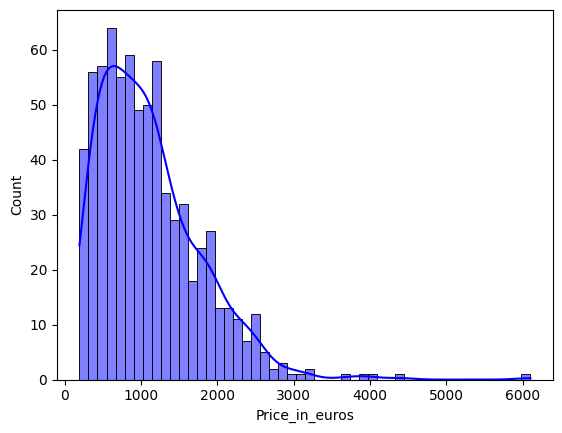

In [148]:
sns.histplot(y_train, color='Blue', kde = True,bins=50)
plt.show()

In [149]:
drop = [ 'Product', 'ScreenResolution', 'Cpu','Ram', 'Memory', 'Gpu', 'Weight']

In [150]:
X_train_final= X_train_conca.copy()
X_test_final = X_test_conca.copy()

In [151]:
X_train_final = X_train_conca.drop(columns = drop)
X_test_final = X_test_conca.drop(columns = drop)

In [152]:
X_train_final.shape

(729, 75)

In [52]:
# tl.describe_df(X_train_final)

In [75]:
# tl.tipifica_variables(X_train_final)

In [153]:
binaria = tl.tipifica_variables(X_train_final)['Categorica_Binaria']
categorica = tl.tipifica_variables(X_train_final)['Categorica_Nominal']
num_discreta = tl.tipifica_variables(X_train_final)['Numerica_Discreta']
num_continua = tl.tipifica_variables(X_train_final)['Numerica_Continua']

In [154]:
numericas = num_continua + num_discreta + categorica

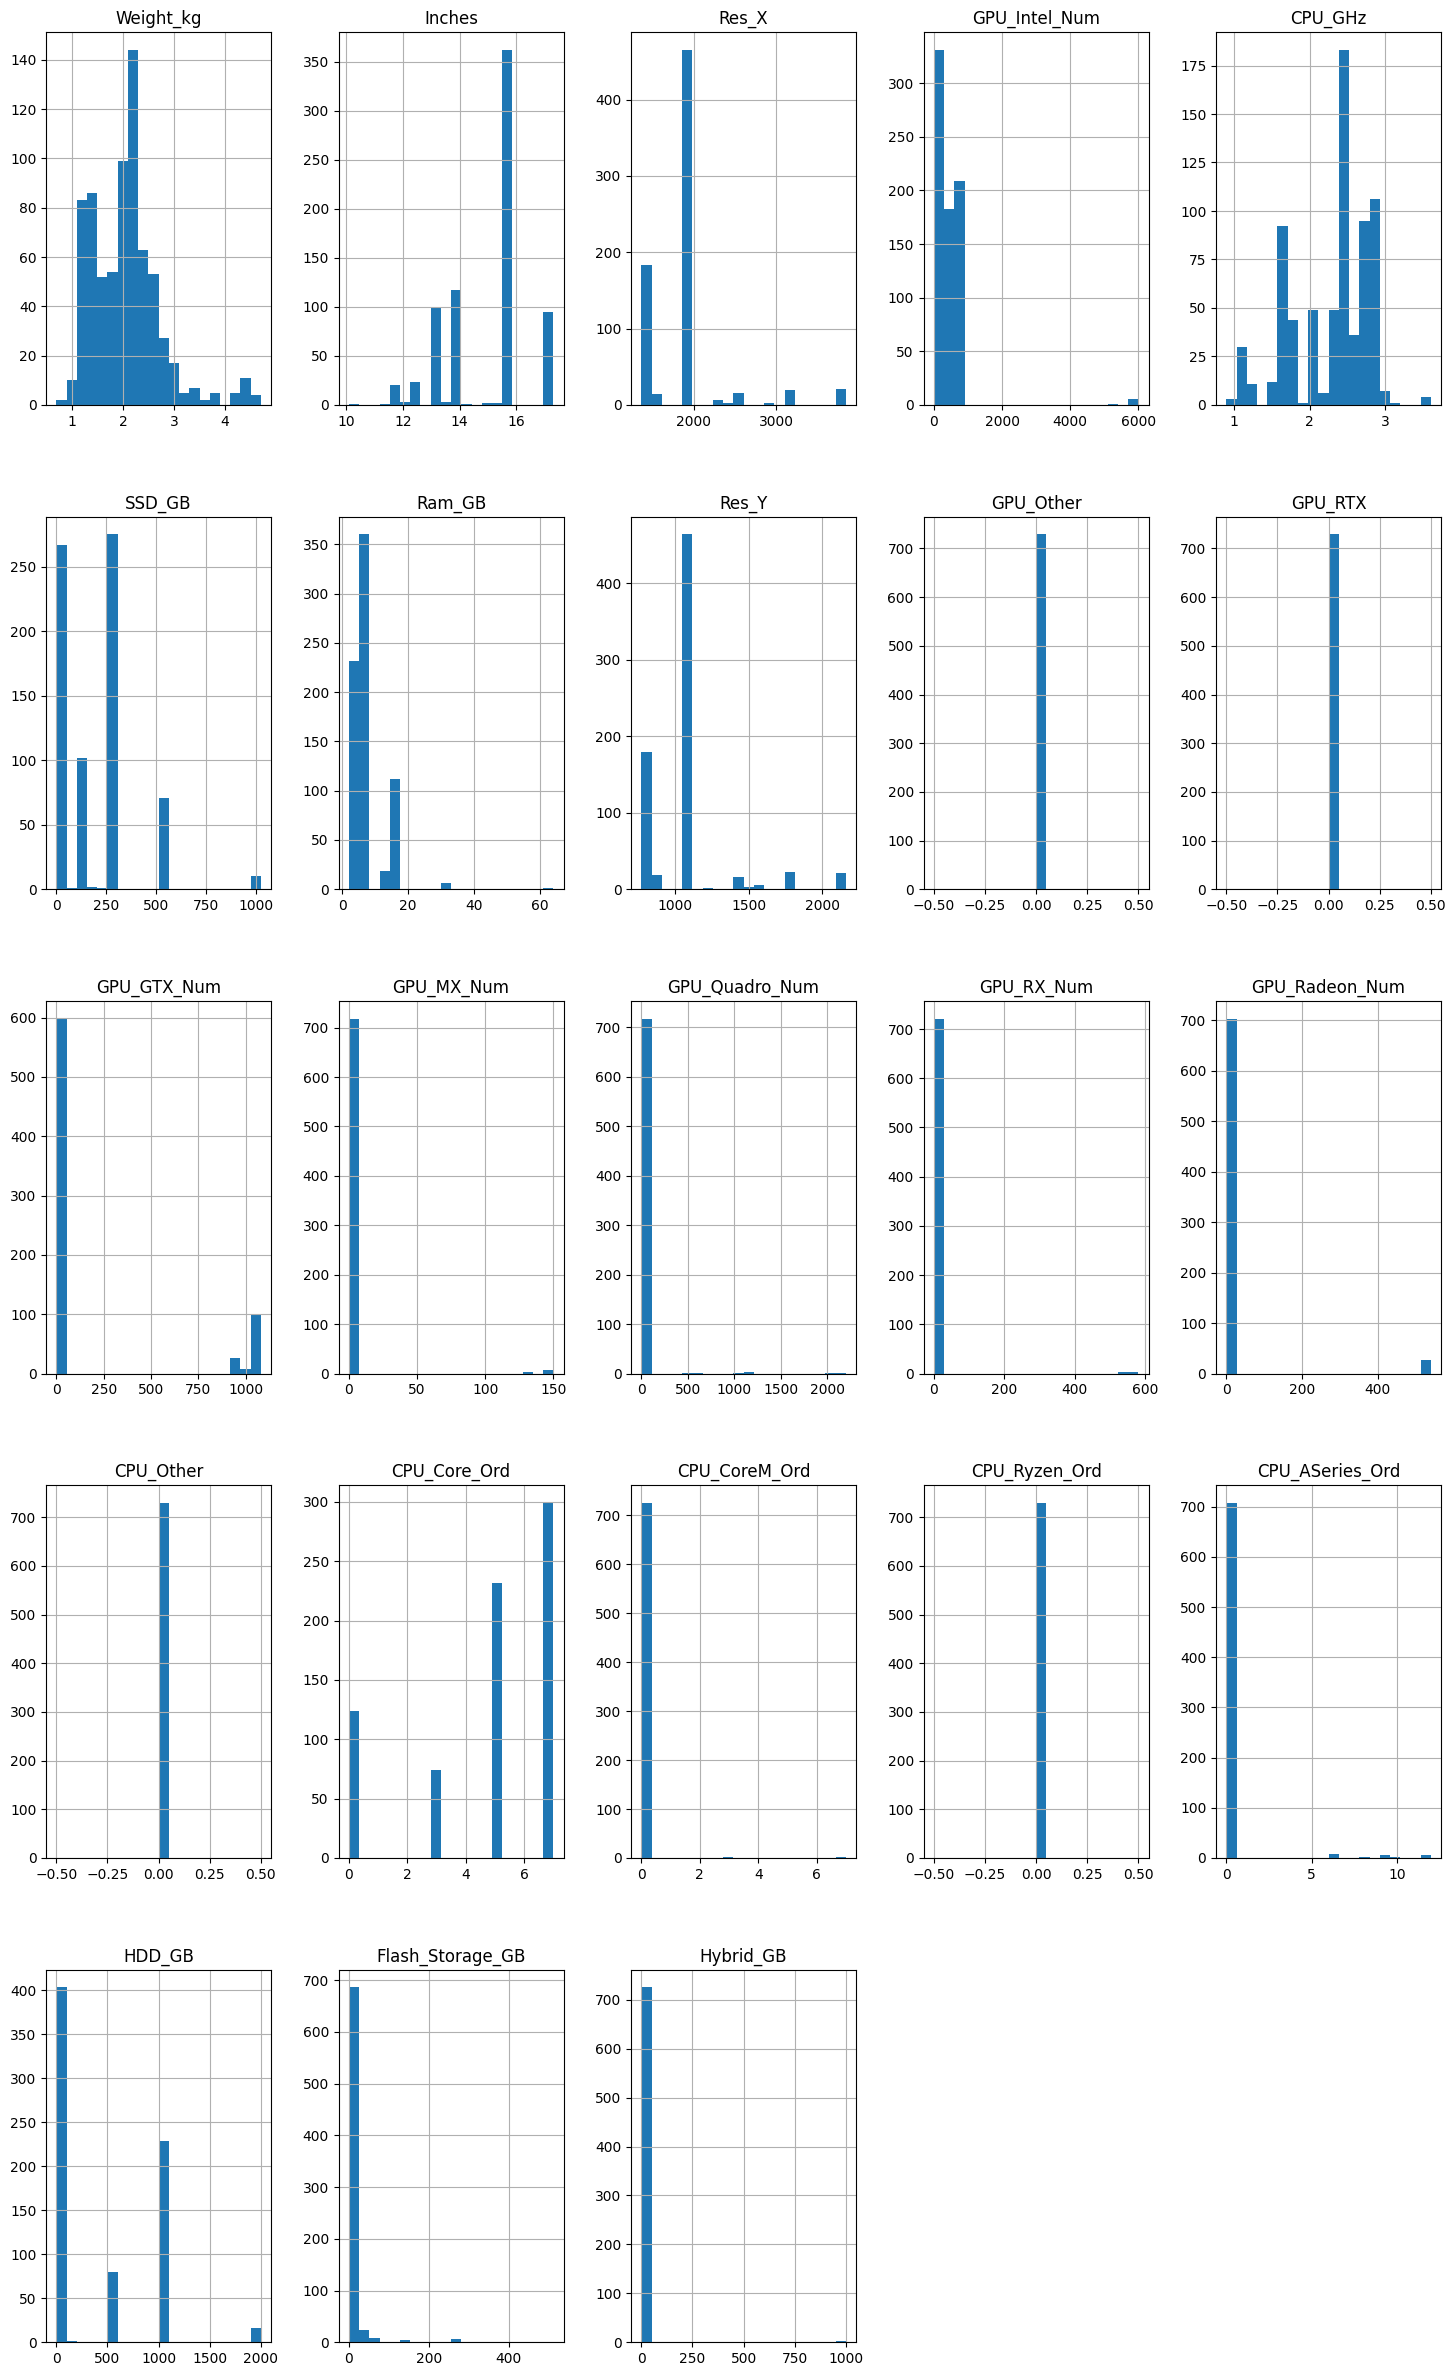

In [155]:
X_train_final[numericas].hist(bins=20, figsize=(18, 30));

In [156]:
dataset = X_train_final.copy()
dataset['Price_in_euros'] = y_train
dataset_test = X_test_final.copy()
dataset_test['Price_in_euros'] = y_test

##### Si saco los outliers

In [60]:
out_target = dataset['Price_in_euros']> 4000
# sns.histplot(dataset[~out_target]['Price_in_euros'], color='Blue', kde = True,bins=50)
# plt.show()
dataset = dataset[~out_target]
X_train_2 = dataset.drop(columns= 'Price_in_euros')
y_train_2 = dataset['Price_in_euros']

In [85]:
# print(dataset.shape)
# print(X_train_2.shape)
# print(y_train_2.shape)

In [62]:
out_target = dataset_test['Price_in_euros'] > 4000
dataset_test = dataset_test[~out_target]
X_test_2 = dataset_test.drop(columns= 'Price_in_euros')
y_test_2 = dataset_test['Price_in_euros']

In [63]:
# for col in binaria:
#     bt.plot_grouped_histograms(dataset,col, target, group_size =2)

#### Estacalado para modelos que lo necesiten 

In [157]:
X_train_sc = X_train_final.copy()
X_test_sc  = X_test_final .copy()

scaler = StandardScaler()
X_train_sc[numericas] = scaler.fit_transform(X_train_sc[numericas])
X_test_sc[numericas] = scaler.transform(X_test_sc[numericas])

-----------------------------------------------------------------------------------------------------------------

## 4. Modelado

### 4.1 Baseline de modelos


In [65]:
# X_train = X_train[features_num]
# X_test = X_test[features_num]

In [158]:
rf_reg = RandomForestRegressor(max_depth=5, random_state = 42)

In [159]:
rf_reg.fit(X_train_final,y_train)

RandomForestRegressor(max_depth=5, random_state=42)

### 4.2 Sacar métricas, valorar los modelos

Recuerda que en la competición se va a evaluar con la métrica de ``RMSE``.

In [160]:
y_pred = rf_reg.predict(X_test_final)

In [161]:
root_mean_squared_error(y_test,y_pred)

np.float64(356.1514505490026)

### 4.3 Optimización (up to you 🫰🏻)

In [70]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.neighbors import  KNeighborsRegressor


lr_reg = LinearRegression()
tree_reg = DecisionTreeRegressor(max_depth=5, random_state= 42)
rf_reg = RandomForestRegressor(max_depth=5, random_state= 42)
xgb_reg = XGBRegressor(max_depth=5, random_state = 42)
lgb_reg = LGBMRegressor(max_depth=5, random_state= 42, verbose = -100)
cat_reg = CatBoostRegressor(depth=5, random_state= 42, verbose = False)
knn_reg_3 = KNeighborsRegressor(n_neighbors= 3)
knn_reg_5 = KNeighborsRegressor(n_neighbors= 5)

model_names = ["Regresion Lineal","DecisionTree","Random Forest","XGBoost","LightGBM","CatBoost","KNN_3", "KNN_5"]
model_set = [lr_reg, tree_reg, rf_reg, xgb_reg, lgb_reg, cat_reg, knn_reg_3,knn_reg_5 ]


In [71]:
metricas_cv = {}
valores = []
for nombre,modelo in zip(model_names, model_set):
    print(modelo)
    if nombre == "Regresion Lineal" or nombre == "KNN_3" or nombre == "KNN_5":
        metricas_cv[nombre] = cross_val_score(modelo, X_train_sc, y_train, cv = 3, scoring = "neg_mean_squared_error")
    else:
        metricas_cv[nombre] = cross_val_score(modelo, X_train_final, y_train, cv = 3, scoring = "neg_mean_squared_error")
    valores.append(np.mean(metricas_cv[nombre]))
ganador = list(metricas_cv.keys())[np.argmax(valores)]

LinearRegression()
DecisionTreeRegressor(max_depth=5, random_state=42)
RandomForestRegressor(max_depth=5, random_state=42)
XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)
LGBMRegressor(max_depth=5, random_state=42, verbose=-100)
KNeighborsRegressor(n_neighbors=3)
KNeighborsRegressor()


In [72]:
for model_name, valores in metricas_cv.items():
    print(f"Model <{model_name}>, RMSE_CV: {np.sqrt(-np.mean(valores))}")
print(f"El ganador es {ganador}")

Model <Regresion Lineal>, RMSE_CV: 151151984696150.6
Model <DecisionTree>, RMSE_CV: 388.19982976003547
Model <Random Forest>, RMSE_CV: 333.2724870149553
Model <XGBoost>, RMSE_CV: 304.835624145355
Model <LightGBM>, RMSE_CV: 315.2577365074099
Model <CatBoost>, RMSE_CV: 266.8463417835839
Model <KNN_3>, RMSE_CV: 334.4221370832766
Model <KNN_5>, RMSE_CV: 340.3961602092181
El ganador es CatBoost


### Ajuste de hiperparametros

| Grupo                | Hiperparámetro                   | Qué hace                  | Si lo subís…              | Entonces compensá con…                                    | Rangos típicos en tu caso     |
| -------------------- | -------------------------------- | ------------------------- | ------------------------- | --------------------------------------------------------- | ----------------------------- |
| Capacidad            | `depth`                          | Complejidad del árbol     | Más riesgo de sobreajuste | ↑ `l2_leaf_reg`, ↑ `min_data_in_leaf`, ↓ `rsm`, + bagging | 3–6               |
| Aprendizaje          | `learning_rate`                  | Tamaño de paso            | Más rápido, más overfit   | ↓ `iterations` o usar early stopping                      | 0.03–0.12                     |
| Aprendizaje          | `iterations`                     | Nº árboles                | Más capacidad             | ↓ `learning_rate` + early stopping                        | 1500–8000         |
| Regularización       | `l2_leaf_reg`                    | Penaliza hojas            | Menos overfit, más sesgo  | Podés permitir ↑ depth                                    | 3–30   |
| Regularización       | `min_data_in_leaf`               | Min muestras por hoja     | Menos overfit             | Podés permitir ↑ depth / ↑ iterations                     | 5–50      |
| Aleatoriedad         | `random_strength`                | Ruido en split score      | Regulariza                | Si subís mucho, puede underfit                            | 1–15    |
| Submuestreo filas    | `subsample` (con Bernoulli)      | Menos varianza            | Puede subir sesgo         | Compensá con ↑ iterations o ↑ depth                       | 0.6–1.0                       |
| Bagging              | `bagging_temperature` (Bayesian) | Regulariza con pesos      | Menos overfit             | A veces permite ↑ depth                                   | 0–10                          |
| Submuestreo columnas | `rsm`                            | Menos overfit (colsample) | Menos varianza, más sesgo | Si bajás mucho, subí depth/iter                           | 0.4–1.0                       |
| Binning numéricas    | `border_count`                   | Nº cortes en numéricas    | Más detalle, más ruido    | Para dataset chico conviene bajarlo                       | 32–128           |
| Optimización hojas   | `leaf_estimation_iterations`     | Refinamiento hoja         | Ajuste fino               | Si lo subís mucho puede overfit                           | 1–10        |


#### Ajuste nº1 -- Lo subi 2do (RMSE = 290.13118)

In [86]:
from sklearn.model_selection import GridSearchCV

cb = CatBoostRegressor(loss_function="RMSE", random_seed=42, verbose=0)

param_grid = {
    "depth": [4, 6, 8],
    "learning_rate": [0.03, 0.05, 0.1],
    "iterations": [500, 1000],
    "l2_leaf_reg": [1, 3, 5, 7],
    "subsample": [0.8, 1.0],             
    "rsm": [0.8, 1.0]                    
}

grid = GridSearchCV(
    estimator=cb,
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",
    cv=5,
    n_jobs=-1,
    verbose=0
)

grid.fit(X_train_final, y_train)

print("Mejores hiperparámetros:", grid.best_params_)
print("Mejor RMSE (CV):", -grid.best_score_)

best_model = grid.best_estimator_

C:\Users\Usuario\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\ma\core.py:2896: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


Mejores hiperparámetros: {'depth': 4, 'iterations': 1000, 'l2_leaf_reg': 1, 'learning_rate': 0.1, 'rsm': 0.8, 'subsample': 1.0}
Mejor RMSE (CV): 248.7885561678927


In [88]:
y_pred = best_model.predict(X_test_final)
root_mean_squared_error(y_test,y_pred)

np.float64(260.3592184788762)

In [ ]:
# np.sqrt(-np.mean(cross_val_score(best_model, X_train_final, y_train, cv = 5, scoring = "neg_root_mean_squared_error")))

#### Ajuste nº 2 -- Lo subi 1ro (RMSE = 296.55131)

In [99]:
cb = CatBoostRegressor(loss_function="RMSE", random_seed=42, verbose=0)

param_grid = {
    "depth": [4, 6, 8,10],
    "learning_rate": [0.03, 0.1],
    "iterations": [500,750, 1000],
    "l2_leaf_reg": [1, 3, 10],
    "subsample": [0.8, 1.0],
    "min_data_in_leaf":[5, 20, 50]
}

grid_2 = GridSearchCV(
    estimator= cb,
    param_grid= param_grid,
    scoring="neg_root_mean_squared_error",
    cv=5,
    n_jobs=-1,
    verbose=0
)

grid_2.fit(X_train_final, y_train)

print("Mejores hiperparámetros:", grid_2.best_params_)
print("Mejor RMSE (CV):", -grid_2.best_score_)

best_model_2 = grid_2.best_estimator_

C:\Users\Usuario\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\ma\core.py:2896: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


Mejores hiperparámetros: {'depth': 4, 'iterations': 750, 'l2_leaf_reg': 3, 'learning_rate': 0.1, 'min_data_in_leaf': 5, 'subsample': 0.8}
Mejor RMSE (CV): 250.34569678616967


In [100]:
np.sqrt(-np.mean(cross_val_score(best_model_2, X_train_final, y_train, cv = 5, scoring = "neg_mean_squared_error")))

np.float64(254.05626596032377)

#### Ajuste nº 3

In [189]:
xgb_reg = XGBRegressor(objective="reg:squarederror",random_state=42, n_jobs= -1,tree_method="hist" )

param_grid = {'max_depth': [3, 4, 5, 6, 8],
              'learning_rate': [0.01, 0.05, 0.1],
              'subsample': np.arange(0.5, 1.0, 0.1),
              'colsample_bytree': np.arange(0.5, 1.0, 0.1),
              'min_child_weight': [1,3,5,10],
              'n_estimators': [500, 750, 1000, 1500, 1750, 2000],
              'gamma': [0,0.1,0.3,1],
              'reg_lambda': [1, 3, 10],
              'reg_alpha': [0, 0.1, 1]
          }

xgb_grid = RandomizedSearchCV(xgb_reg, 
                               cv = 5,
                               n_iter = 50,
                               param_distributions= param_grid, 
                               scoring ="neg_root_mean_squared_error")


xgb_grid.fit(X_train_final, y_train)

print("Mejores hiperparámetros:", xgb_grid.best_params_)
print("Mejor RMSE (CV):", -xgb_grid.best_score_)

best_model_3 = xgb_grid.best_estimator_

Mejores hiperparámetros: {'subsample': np.float64(0.5), 'reg_lambda': 1, 'reg_alpha': 0.1, 'n_estimators': 1750, 'min_child_weight': 3, 'max_depth': 8, 'learning_rate': 0.01, 'gamma': 0, 'colsample_bytree': np.float64(0.8999999999999999)}
Mejor RMSE (CV): 253.7073302317839


In [190]:
np.sqrt(-np.mean(cross_val_score(best_model_3, X_train_final, y_train, cv = 5, scoring = "neg_mean_squared_error")))

np.float64(258.94407071721486)

#### Ajuste nº 4

In [191]:
xgb_reg = XGBRegressor(objective="reg:squarederror",
                       random_state=42,
                       n_jobs= -1,
                       tree_method="hist",
                       max_depth = 8,
                       learning_rate = 0.01,
                       n_estimators = 1750
                      )

param_grid = { "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "min_child_weight": [1, 3, 5, 10],
    "gamma": [0, 0.1, 0.3, 1],
    "reg_lambda": [1, 3, 10],
    "reg_alpha": [0, 0.1, 1],
          }

xgb_grid = GridSearchCV(
    estimator= xgb_reg,
    param_grid= param_grid,
    scoring="neg_root_mean_squared_error",
    cv=5,
    n_jobs=-1,
    verbose=0
)


xgb_grid.fit(X_train_final, y_train)

print("Mejores hiperparámetros:", xgb_grid.best_params_)
print("Mejor RMSE (CV):", -xgb_grid.best_score_)

best_model_4 = xgb_grid.best_estimator_

Mejores hiperparámetros: {'colsample_bytree': 0.7, 'gamma': 1, 'min_child_weight': 3, 'reg_alpha': 0.1, 'reg_lambda': 3, 'subsample': 0.7}
Mejor RMSE (CV): 256.43018338103155


In [192]:
np.sqrt(-np.mean(cross_val_score(best_model_4, X_train_final, y_train, cv = 5, scoring = "neg_mean_squared_error")))

np.float64(263.1213192137085)

#### Ajuste nº 5 -- Lo subi 3ro (RMSE = 270.85636)

In [194]:
cb = CatBoostRegressor(loss_function="RMSE", random_seed=42, verbose=0, depth =  4, iterations = 750,
                       learning_rate= 0.1)

param_grid = {
    "l2_leaf_reg": [1, 3, 5, 10],
    "min_data_in_leaf": [5, 20, 50],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "rsm": [0.6, 0.8, 1.0],
    "random_strength": [0, 1, 2, 5],
    "bagging_temperature": [0, 1, 3]
}

grid_2 = GridSearchCV(
    estimator= cb,
    param_grid= param_grid,
    scoring="neg_root_mean_squared_error",
    cv=5,
    n_jobs=-1,
    verbose=0
)

grid_2.fit(X_train_final, y_train)

print("Mejores hiperparámetros:", grid_2.best_params_)
print("Mejor RMSE (CV):", -grid_2.best_score_)

best_model_2 = grid_2.best_estimator_

C:\Users\Usuario\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\ma\core.py:2896: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


Mejores hiperparámetros: {'bagging_temperature': 0, 'l2_leaf_reg': 1, 'min_data_in_leaf': 5, 'random_strength': 5, 'rsm': 0.8, 'subsample': 0.8}
Mejor RMSE (CV): 247.46176039467755


In [195]:
np.sqrt(-np.mean(cross_val_score(best_model_2, X_train_final, y_train, cv = 5, scoring = "neg_mean_squared_error")))

np.float64(249.9912352032283)

#### nº5.1 ¿Distribucion normal al target ?

In [213]:
y_train_log = np.log1p(y_train)

In [215]:
model_log = best_model_2
model_log.fit(X_train_final, y_train_log)

In [218]:
y_pred_log = model_log.predict(X_test_final)
y_pred = np.expm1(y_pred_log)
root_mean_squared_error(y_test,y_pred)

np.float64(269.5596893780733)

#### Ajuste nº 6

In [72]:
cb = CatBoostRegressor(loss_function="RMSE",
                       random_seed=42, 
                       verbose=0, 
                       depth =  4, 
                       iterations = 750, 
                       learning_rate= 0.1,
                       min_data_in_leaf = 5,
                       bootstrap_type="Bayesian" # para bagging_temperature
                      )

param_grid = {
    "l2_leaf_reg": [1, 3, 5, 10,20 ,50],
    "rsm": [0.6, 0.8, 1.0],
    "random_strength": [0, 1, 2, 5],
    "bagging_temperature": [0, 1, 3,5,10]
}

grid = GridSearchCV(
    estimator= cb,
    param_grid= param_grid,
    scoring="neg_root_mean_squared_error",
    cv=5,
    n_jobs=-1,
    verbose=0
)

grid.fit(X_train_final, y_train)

print("Mejores hiperparámetros:", grid.best_params_)
print("Mejor RMSE (CV):", -grid.best_score_)

best_model_6 = grid.best_estimator_

Mejores hiperparámetros: {'depth': 7, 'min_data_in_leaf': 40}
Mejor RMSE (CV): 260.0171542439368


In [200]:
np.sqrt(-np.mean(cross_val_score(best_model_6, X_train_final, y_train, cv = 5, scoring = "neg_mean_squared_error")))

np.float64(251.13062343544536)

#### Ajuste nº 7 -- Lo subi 4ro (RMSE = 267.60104)

In [114]:
cb = CatBoostRegressor(loss_function="RMSE", random_seed=42, verbose=0, depth =  4, iterations = 750,
                       learning_rate= 0.1,
                      l2_leaf_reg= 1, min_data_in_leaf= 5, rsm= 0.8)
param_grid = {
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "random_strength": [0, 1, 2, 5,10,15],
    "leaf_estimation_iterations": [1, 3, 5, 10],
    "border_count": [32, 64, 128, 254]
}

grid = GridSearchCV(
    estimator= cb,
    param_grid= param_grid,
    scoring="neg_root_mean_squared_error",
    cv=5,
    n_jobs=-1,
    verbose=0
    
)

grid.fit(X_train_final, y_train)

print("Mejores hiperparámetros:", grid.best_params_)
print("Mejor RMSE (CV):", -grid.best_score_)

best_model_7_1 = grid.best_estimator_

Mejores hiperparámetros: {'border_count': 64, 'leaf_estimation_iterations': 5, 'random_strength': 5, 'subsample': 1.0}
Mejor RMSE (CV): 242.34958039822294


In [115]:
rmse_cv = -cross_val_score(
    best_model_7,
    X_train_final,
    y_train,
    cv=5,
    scoring="neg_root_mean_squared_error"
).mean()

rmse_cv


np.float64(255.21023032949924)

In [84]:
X_full = pd.concat([X_train_final, X_test_final], axis=0)
y_full = pd.concat([y_train, y_test], axis=0)
X_full.head()

,Inches,Company_Acer,Company_Apple,Company_Asus,Company_Chuwi,Company_Dell,Company_Fujitsu,Company_Google,Company_HP,Company_Lenovo,...,CPU_Atom,CPU_ESeries,CPU_OtherFamily,CPU_GHz,SSD_GB,HDD_GB,Flash_Storage_GB,Hybrid_GB,Ram_GB,Weight_kg
laptop_ID,,,,,,,,,,,,,,,,,,,,,
1118,17.3,0,0,0,0,0,0,0,1,0,...,0,0,0,2.6,0.0,1000.0,0.0,0.0,8,3.00
153,15.6,0,0,0,0,1,0,0,0,0,...,0,0,0,2.8,512.0,0.0,0.0,0.0,16,2.56
275,13.3,0,1,0,0,0,0,0,0,0,...,0,0,0,2.9,512.0,0.0,0.0,0.0,8,1.37
1100,14.0,0,0,0,0,0,0,0,1,0,...,0,0,0,2.3,0.0,500.0,0.0,0.0,4,1.54
131,17.3,0,0,0,0,1,0,0,0,0,...,0,0,0,1.8,256.0,2000.0,0.0,0.0,16,2.80


In [80]:
X_train_final.shape

(729, 75)

In [81]:
X_full.shape

(912, 75)

In [85]:
y_full.shape

(912,)

#### Lo subi 7ro (RMSE = 264.48850)

In [86]:
cb = CatBoostRegressor(loss_function="RMSE", random_seed=42, verbose=0, depth =  4, iterations = 750,
                       learning_rate= 0.1,
                      l2_leaf_reg= 1, min_data_in_leaf= 5, rsm= 0.8)
param_grid = {
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "random_strength": [0, 1, 2, 5,10,15],
    "leaf_estimation_iterations": [1, 3, 5, 10],
    "border_count": [32, 64, 128, 254]
}

grid = GridSearchCV(
    estimator= cb,
    param_grid= param_grid,
    scoring="neg_root_mean_squared_error",
    cv=5,
    n_jobs=-1,
    verbose=0
    
)

grid.fit(X_full , y_full)

print("Mejores hiperparámetros:", grid.best_params_)
print("Mejor RMSE (CV):", -grid.best_score_)

best_model_7 = grid.best_estimator_

Mejores hiperparámetros: {'border_count': 64, 'leaf_estimation_iterations': 10, 'random_strength': 15, 'subsample': 0.8}
Mejor RMSE (CV): 227.62133773521253


#### Ajuste 7 2.0 - Lo subi 8vo - 271.33699

In [116]:
from sklearn.model_selection import KFold
cb = CatBoostRegressor(loss_function="RMSE", random_seed=42, verbose=0, depth =  4, iterations = 750,
                       learning_rate= 0.1,
                      l2_leaf_reg= 1, min_data_in_leaf= 5, rsm= 0.8)

cv = KFold(n_splits=5,shuffle=True, random_state=42)

param_grid = {
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "random_strength": [0, 1, 2, 5,10,15],
    "leaf_estimation_iterations": [1, 3, 5, 10],
    "border_count": [32, 64, 128, 254]
}

grid = GridSearchCV(
    estimator= cb,
    param_grid= param_grid,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    n_jobs=-1,
    verbose=0
    
)

grid.fit(X_train_final, y_train)

print("Mejores hiperparámetros:", grid.best_params_)
print("Mejor RMSE (CV):", -grid.best_score_)

best_model_7_2 = grid.best_estimator_


Mejores hiperparámetros: {'border_count': 254, 'leaf_estimation_iterations': 10, 'random_strength': 15, 'subsample': 1.0}
Mejor RMSE (CV): 239.98082137941805


In [119]:
rmse_cv = -cross_val_score(
    best_model_7_2,
    X_train_final,
    y_train,
    cv=cv,
    scoring="neg_root_mean_squared_error"
).mean()

rmse_cv

np.float64(239.98082137941805)

In [121]:
cb = CatBoostRegressor(loss_function="RMSE", random_seed=42, verbose=0, depth =  4, iterations = 750,
                       learning_rate= 0.1,
                      l2_leaf_reg= 1, min_data_in_leaf= 5, rsm= 0.8)

cv = KFold(n_splits=5,shuffle=True, random_state=42)

param_grid = {
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "random_strength": [0, 1, 2, 5,10,15],
    "leaf_estimation_iterations": [1, 3, 5, 10],
    "border_count": [32, 64, 128, 254]
}

grid = GridSearchCV(
    estimator= cb,
    param_grid= param_grid,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    n_jobs=-1,
    verbose=0
    
)

grid.fit(X_full , y_full)

print("Mejores hiperparámetros:", grid.best_params_)
print("Mejor RMSE (CV):", -grid.best_score_)

best_model_7_pluss = grid.best_estimator_

Mejores hiperparámetros: {'border_count': 32, 'leaf_estimation_iterations': 10, 'random_strength': 10, 'subsample': 0.8}
Mejor RMSE (CV): 223.88137633158559


#### Ajuste nº 8

In [77]:
cb = CatBoostRegressor(
    loss_function="RMSE",
    random_seed=42,
    verbose=0,
    depth=4,
    iterations=750,
    learning_rate=0.1,
    rsm=0.8,
    border_count=64,
    leaf_estimation_iterations=5,
    random_strength=5,
    subsample=1.0
)

param_grid = {
    "l2_leaf_reg": [1, 3, 5, 10, 20],
    "min_data_in_leaf": [1, 3, 5, 10, 20]
}


grid = GridSearchCV(
    estimator=cb,
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",
    cv=5,
    n_jobs=-1,
    verbose=0
)

grid.fit(X_train_final, y_train)

print("Mejores hiperparámetros:", grid.best_params_)
print("Mejor RMSE (CV):", -grid.best_score_)

best_model_8 = grid.best_estimator_

Mejores hiperparámetros: {'l2_leaf_reg': 1, 'min_data_in_leaf': 1}
Mejor RMSE (CV): 242.34958039822294


In [78]:
-np.mean(cross_val_score(best_model_8, X_train_final, y_train, cv = 5, scoring = "neg_root_mean_squared_error"))

np.float64(242.34958039822294)

#### Ajuste nº 9

In [74]:
cb = CatBoostRegressor(
    loss_function='RMSE',
    eval_metric= 'RMSE',
    iterations=8000,
    early_stopping_rounds = 300,
    random_seed = 42,
    verbose = False,
    bootstrap_type = 'Bayesian')
    
    

param_grid = {'depth': [5, 6, 7],
              'min_data_in_leaf': [40, 70, 100]
}


grid = GridSearchCV(
    estimator=cb,
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",
    cv=5,
    n_jobs=-1,
    verbose=0
)

grid.fit(X_train_final, y_train)

print("Mejores hiperparámetros:", grid.best_params_)
print("Mejor RMSE (CV):", -grid.best_score_)

best_model_9 = grid.best_estimator_

Mejores hiperparámetros: {'depth': 5, 'min_data_in_leaf': 40}
Mejor RMSE (CV): 254.94194296842093


In [76]:
-np.mean(cross_val_score(best_model_9, X_train_final, y_train, cv = 5, scoring = "neg_root_mean_squared_error"))

np.float64(254.94194296842093)

#### Ajuste 10 

In [74]:
from sklearn.model_selection import KFold

cv = KFold(n_splits=5, shuffle=True, random_state=42)
cb = CatBoostRegressor(loss_function='RMSE', random_seed=42, verbose=0, depth =  4, iterations = 750, learning_rate= 0.1,
                      l2_leaf_reg= 1, rsm= 0.8, )
param_grid = {
    'min_data_in_leaf': [5, 10, 15, 20],
    'random_strength': [0, 1, 2, 5,10,15],
    'leaf_estimation_iterations': [1, 3, 5, 10],
    'border_count': [32, 64, 128, 254]
}

grid = GridSearchCV(
    estimator= cb,
    param_grid= param_grid,
    scoring="neg_root_mean_squared_error",
    cv=5,
    n_jobs=-1,
    verbose=0
    
)

grid.fit(X_train_final, y_train)

print("Mejores hiperparámetros:", grid.best_params_)
print("Mejor RMSE (CV):", -grid.best_score_)

best_model_10 = grid.best_estimator_


C:\Users\Usuario\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\ma\core.py:2896: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


Mejores hiperparámetros: {'border_count': 64, 'leaf_estimation_iterations': 3, 'min_data_in_leaf': 5, 'random_strength': 2}
Mejor RMSE (CV): 246.54924997730785


In [75]:
y_pred = best_model_10.predict(X_test_final)
root_mean_squared_error(y_test,y_pred)

np.float64(265.07041200816)

In [77]:
-np.mean(cross_val_score(best_model_10, X_train_final, y_train, cv = 5, scoring = "neg_root_mean_squared_error"))

np.float64(246.54924997730785)

-----------------------------------------------------------------

## Una vez listo el modelo, toca predecir ``test.csv``

**RECUERDA: APLICAR LAS TRANSFORMACIONES QUE HAYAS REALIZADO EN `train.csv` a `test.csv`.**


Véase:
- Estandarización/Normalización
- Eliminación de Outliers
- Eliminación de columnas
- Creación de columnas nuevas
- Gestión de valores nulos
- Y un largo etcétera de técnicas que como Data Scientist hayas considerado las mejores para tu dataset.

## 1. Carga los datos de `test.csv` para predecir.


In [166]:
X_pred = pd.read_csv("./data/test.csv", index_col = 'laptop_ID')
# X_pred.head()

In [167]:
one_hot = ['Company','TypeName','OpSys']
for col in one_hot:
    X_pred = pd.get_dummies(X_pred, columns=[col], dtype= int)

In [168]:
screen_pr = transformer_screenresolution(X_pred)
cpu_pr = transformer_cpu(X_pred)
memory_pr = transformer_memory(X_pred)
gpu_pr = transformer_gpu(X_pred)

In [169]:
X_pred['Ram_GB'] = X_pred['Ram'].str.replace('GB','').astype(int)
X_pred['Weight_kg'] = X_pred['Weight'].str.replace('kg','').astype(float)

In [170]:
drop = [ 'Product', 'ScreenResolution', 'Cpu','Ram', 'Memory', 'Gpu', 'Weight']
X_pred_final = X_pred.copy()
X_pred_final = X_pred.drop(columns = drop)

In [171]:
X_pred_final = pd.concat([X_pred_final, screen_pr , gpu_pr, cpu_pr,memory_pr], axis=1)
X_pred_final .shape

(391, 75)

In [88]:
# X_pred.tail()

In [89]:
# X_pred.info()

 ## 2. Replicar el procesado para ``test.csv``

In [101]:
# X_pred_final

In [132]:
predictions_submit = best_model_7_pluss.predict(X_pred_final)
predictions_submit

array([1503.26169573,  281.31594661,  348.01274707, 1020.28516255,
       1041.01902429,  413.98609555,  753.0003319 ,  919.67689953,
       1188.72503604,  334.03995046, 1973.42889128, 1357.81381572,
        512.47015705, 1736.69452518,  739.43917527,  700.71719596,
       2293.10938028, 1243.81991587, 1920.66569978,  694.17571678,
       1591.89812283,  254.10561591,  733.11036778, 1039.3058412 ,
        403.69348349,  736.10462798,  527.82561797,  788.24309553,
       3633.88041822, 1113.46656387, 2417.61205378,  425.40786912,
        764.88106437, 2874.99337039, 2545.1254046 , 1611.66431707,
        648.1167237 , 1282.56414052,  978.63707435, 1524.6456489 ,
        552.5277908 ,  725.16507521,  545.33849104, 1342.48011684,
       1017.77288486, 1056.12866336, 1057.38634231,  582.39441395,
        652.47766619,  418.25680165, 1594.70357334,  805.05538218,
       1149.01453789,  531.52488861, 1930.33376573, 1683.46906781,
        797.61458902,  948.34788276,  917.70634915,  635.63993

**¡OJO! ¿Por qué me da error?**

IMPORTANTE:

- SI EL ARRAY CON EL QUE HICISTEIS `.fit()` ERA DE 4 COLUMNAS, PARA `.predict()` DEBEN SER LAS MISMAS
- SI AL ARRAY CON EL QUE HICISTEIS `.fit()` LO NORMALIZASTEIS, PARA `.predict()` DEBÉIS NORMALIZARLO
- TODO IGUAL SALVO **BORRAR FILAS**, EL NÚMERO DE ROWS SE DEBE MANTENER EN ESTE SET, PUES LA PREDICCIÓN DEBE TENER **391 FILAS**, SI O SI

**Entonces, si al cargar los datos de ``train.csv`` usaste `index_col=0`, ¿tendré que hacer lo también para el `test.csv`?**

In [133]:
# ¿Qué opináis?
# ¿Sí, no?

![wow.jpeg](attachment:wow.jpeg)

## 3. **¿Qué es lo que subirás a Kaggle?**

**Para subir a Kaggle la predicción esta tendrá que tener una forma específica.**

En este caso, la **MISMA** forma que `sample_submission.csv`.

In [134]:
sample = pd.read_csv("data/sample_submission.csv")

In [135]:
sample.head()

,laptop_ID,Price_in_euros
0,209,1949.1
1,1281,805.0
2,1168,1101.0
3,1231,1293.8
4,1020,1832.6


In [136]:
sample.shape

(391, 2)

## 4. Mete tus predicciones en un dataframe llamado ``submission``.

In [137]:
#¿Cómo creamos la submission?
submission = pd.DataFrame({
    'laptop_ID': X_pred.index,
    'Price_in_euros' : predictions_submit
})

In [138]:
submission.head()

,laptop_ID,Price_in_euros
0,209,1503.261696
1,1281,281.315947
2,1168,348.012747
3,1231,1020.285163
4,1020,1041.019024


In [139]:
submission.shape

(391, 2)

## 5. Pásale el CHEQUEADOR para comprobar que efectivamente está listo para subir a Kaggle.

In [140]:
def chequeador(df_to_submit):
    """
    Esta función se asegura de que tu submission tenga la forma requerida por Kaggle.

    Si es así, se guardará el dataframe en un `csv` y estará listo para subir a Kaggle.

    Si no, LEE EL MENSAJE Y HAZLE CASO.

    Si aún no:
    - apaga tu ordenador,
    - date una vuelta,
    - enciendelo otra vez,
    - abre este notebook y
    - leelo todo de nuevo.
    Todos nos merecemos una segunda oportunidad. También tú.
    """
    if df_to_submit.shape == sample.shape:
        if df_to_submit.columns.all() == sample.columns.all():
            if df_to_submit.laptop_ID.all() == sample.laptop_ID.all():
                print("You're ready to submit!")
                df_to_submit.to_csv("submission_8.csv", index = False) #muy importante el index = False
                urllib.request.urlretrieve("https://www.mihaileric.com/static/evaluation-meme-e0a350f278a36346e6d46b139b1d0da0-ed51e.jpg", "gfg.png")
                img = Image.open("gfg.png")
                img.show()
            else:
                print("Check the ids and try again")
        else:
            print("Check the names of the columns and try again")
    else:
        print("Check the number of rows and/or columns and try again")
        print("\nMensaje secreto del TA: No me puedo creer que después de todo este notebook hayas hecho algún cambio en las filas de `test.csv`. Lloro.")

In [141]:
chequeador(submission)

You're ready to submit!
